In [1]:
import numpy as np
import matplotlib.pyplot as plt

PART A

In [2]:
# Solve using least squares

m = 5.0
b = 2.0
x0 = np.arange (0,1.01,0.01) #makes points
error = np.random.uniform(-1,1,len(x0)) # +/- error

y0 = m*x0+b+error

A0 = np.vstack([x0, np.ones(len(x0))]).T

m0, c0 = np.linalg.lstsq(A0, y0, rcond=None)[0]

xline = np.linspace(min(x0),(max(x0)),101) # for line x values

yline = m0*xline + c0      # for plotting
yline_data = m0*x0 + c0    # for error calculations

print(f"\nSlope: {m0}, Intercept: {c0}")


Slope: 5.179492397096838, Intercept: 1.864596924337902


In [3]:
# Polynomial fitting using NumPy's polyfit
# Fit a 3rd degree polynomial to the data
degree = 3
coefficients = np.polyfit(x0, y0, degree)

# Print the polynomial coefficients
print("Polynomial Coefficients: ", coefficients)

# Step 3: Use the coefficients to predict y-values (polynomial function)
# Generate polynomial function based on the coefficients
polynomial = np.poly1d(coefficients)


Polynomial Coefficients:  [-0.8307915  -0.80489972  6.73458023  1.56646927]


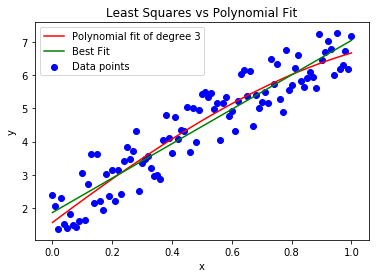

In [4]:
#Generate predicted y-values based on the fitted polynomial
y_pred = polynomial(x0)

plt.scatter(x0, y0, color='blue', label='Data points') # Original data points
plt.plot(x0, y_pred, color='red', label=f'Polynomial fit of degree {degree}')
plt.plot(xline,yline, 'green', label = 'Best Fit') #Plots the best fit line


# Fitted curve
plt.title("Least Squares vs Polynomial Fit")

plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

In [5]:
# Mean Squared Error (MSE) for Polynomial
mse_poly = np.mean((y0 - y_pred)**2)
print(f'Mean Squared Error for poly: {mse_poly:.4f}')

# R-squared value
ss_total = np.sum((y0 - np.mean(y0))**2)
ss_res = np.sum((y0 - y_pred)**2)
r_squared = 1 - (ss_res / ss_total)
print(f'R-squared: {r_squared:.4f}')

Mean Squared Error for poly: 0.3111
R-squared: 0.8811


In [6]:
# Mean Squared Error (MSE) for Best Fit
mse_lin = np.mean((y0 - yline_data)**2)
print(f'Mean Squared Error for lsq: {mse_lin:.4f}')

# R-squared value
ss_total = np.sum((y0 - np.mean(y0))**2)
ss_res = np.sum((y0 - yline_data)**2)
r_squared = 1 - (ss_res / ss_total)
print(f'R-squared: {r_squared:.4f}')

Mean Squared Error for lsq: 0.3357
R-squared: 0.8717


In [7]:
if mse_poly < mse_lin:
    print("Polynomial fit is the better model based on MSE")
else:
    print("Least Squares linear fit is the better model based on MSE")

Polynomial fit is the better model based on MSE


PART B

In [8]:
np.random.seed(0)

# Data
m = 5.0
b = 2.0
start_deg = 3

x0 = np.arange(0,1.01,0.01)
error = np.random.uniform(-1,1,len(x0))
y0 = m*x0 + b + error

A0 = np.vstack([x0, np.ones(len(x0))]).T
m0, c0 = np.linalg.lstsq(A0, y0, rcond=None)[0]

xline = np.linspace(min(x0),(max(x0)),101) # for line x values
yline = m0*xline + c0      # for plotting
yline_data = m0*x0 + c0    # for error calculations

ss_total = np.sum((y0 - np.mean(y0))**2)

MSE_lsq: 0.3123
R_squared_lsq: 0.8483

Degree 3
MSE_polyfit: 0.3082
R_squared_polyfit: 0.8503


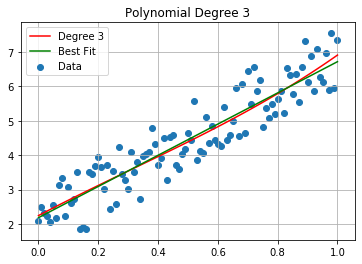

MSE_lsq: 0.3123
R_squared_lsq: 0.8483

Degree 4
MSE_polyfit: 0.3073
R_squared_polyfit: 0.8508


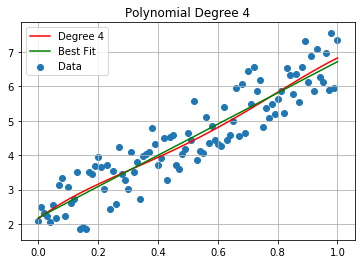

MSE_lsq: 0.3123
R_squared_lsq: 0.8483

Degree 5
MSE_polyfit: 0.3072
R_squared_polyfit: 0.8508


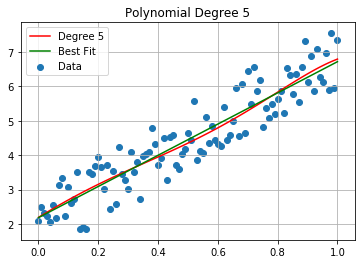

MSE_lsq: 0.3123
R_squared_lsq: 0.8483

Degree 6
MSE_polyfit: 0.3066
R_squared_polyfit: 0.8511


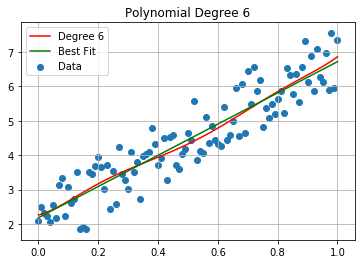

MSE_lsq: 0.3123
R_squared_lsq: 0.8483

Degree 7
MSE_polyfit: 0.3063
R_squared_polyfit: 0.8513


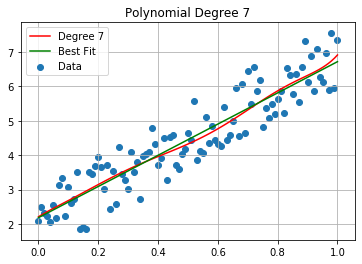

MSE_lsq: 0.3123
R_squared_lsq: 0.8483

Degree 8
MSE_polyfit: 0.3054
R_squared_polyfit: 0.8517


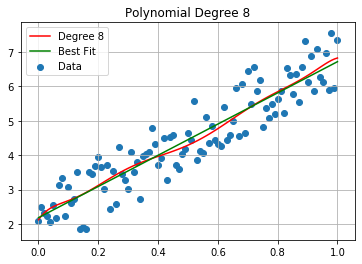

MSE_lsq: 0.3123
R_squared_lsq: 0.8483

Degree 9
MSE_polyfit: 0.3054
R_squared_polyfit: 0.8517


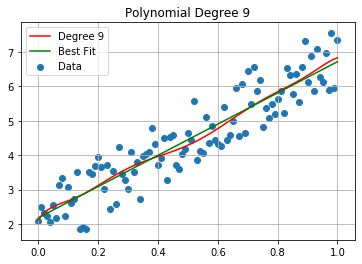

MSE_lsq: 0.3123
R_squared_lsq: 0.8483

Degree 10
MSE_polyfit: 0.3022
R_squared_polyfit: 0.8532


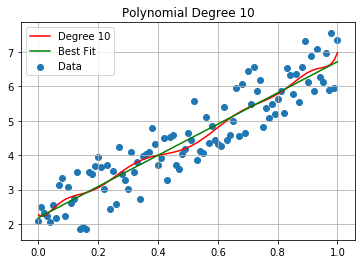

MSE_lsq: 0.3123
R_squared_lsq: 0.8483

Degree 11
MSE_polyfit: 0.2946
R_squared_polyfit: 0.857


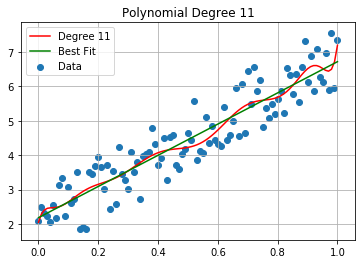

MSE_lsq: 0.3123
R_squared_lsq: 0.8483

Degree 12
MSE_polyfit: 0.2923
R_squared_polyfit: 0.8581


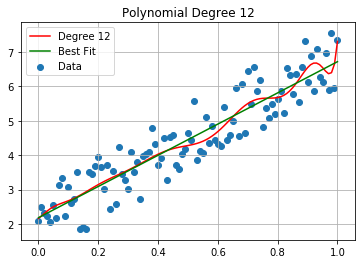

MSE_lsq: 0.3123
R_squared_lsq: 0.8483

Degree 13
MSE_polyfit: 0.2866
R_squared_polyfit: 0.8608


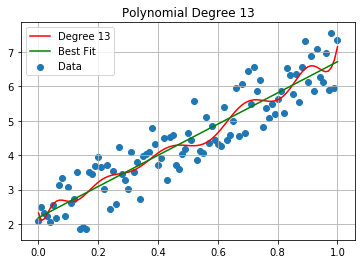

MSE_lsq: 0.3123
R_squared_lsq: 0.8483

Degree 14
MSE_polyfit: 0.2862
R_squared_polyfit: 0.861


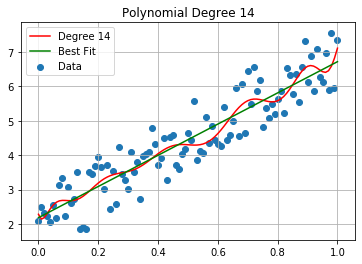

MSE_lsq: 0.3123
R_squared_lsq: 0.8483

Degree 15
MSE_polyfit: 0.2861
R_squared_polyfit: 0.8611


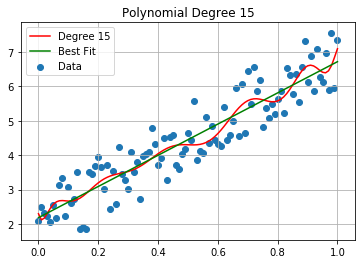

In [9]:
#Degrees upward (until overfit)

for degree in range(start_deg,16):

    coeffs = np.polyfit(x0, y0, degree)
    poly = np.poly1d(coeffs)
    y_pred = poly(x0)

    mse = np.mean((y0 - y_pred)**2)
    r2 = 1 - np.sum((y0 - y_pred)**2)/ss_total
    
    mse_lin = np.mean((y0 - yline_data)**2)
    ss_res = np.sum((y0 - yline_data)**2)
    r_squared = 1 - (ss_res / ss_total)

    # Mean Squared Error (MSE) and R-squared value for Best Fit
    print(f'MSE_lsq: {mse_lin:.4f}')
    print(f'R_squared_lsq: {r_squared:.4f}')

    # Mean Squared Error (MSE) and R-squared value for Poly Fit
    print(f"\nDegree {degree}")
    print("MSE_polyfit:", round(mse,4))
    print("R_squared_polyfit:", round(r2,4))

    # Plotting
    plt.figure()
    plt.scatter(x0,y0,label="Data")
    plt.plot(x0,y_pred,'red', label=f"Degree {degree}") # Plots Polyfit
    plt.plot(xline,yline, 'green', label = 'Best Fit') #Plots the best fit line
    plt.title(f"Polynomial Degree {degree}")
    plt.legend()
    plt.grid(True)
    plt.show()

MSE_lsq: 0.3123
R_squared_lsq: 0.8483

Degree 3
MSE_polyfit: 0.3082
R_squared_polyfit: 0.8503


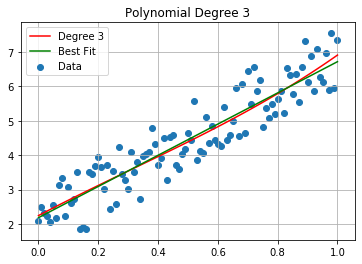

MSE_lsq: 0.3123
R_squared_lsq: 0.8483

Degree 2
MSE_polyfit: 0.3089
R_squared_polyfit: 0.85


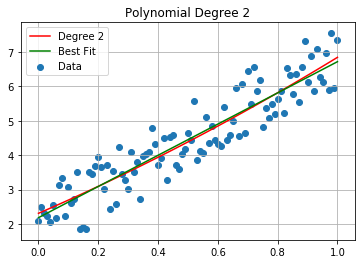

MSE_lsq: 0.3123
R_squared_lsq: 0.8483

Degree 1
MSE_polyfit: 0.3123
R_squared_polyfit: 0.8483


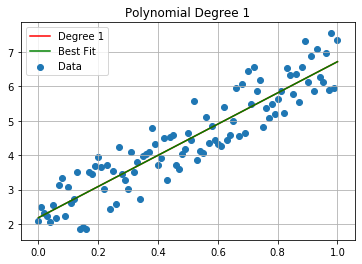

In [10]:
# Degrees downward (until underfit)

for degree in range(start_deg, 0, -1):

    coeffs = np.polyfit(x0, y0, degree)
    poly = np.poly1d(coeffs)
    y_pred = poly(x0)

    mse = np.mean((y0 - y_pred)**2)
    r2 = 1 - np.sum((y0 - y_pred)**2)/ss_total

    # Mean Squared Error (MSE) and R-squared value for Best Fit
    print(f'MSE_lsq: {mse_lin:.4f}')
    print(f'R_squared_lsq: {r_squared:.4f}')

    # Mean Squared Error (MSE) and R-squared value for Poly Fit
    print(f"\nDegree {degree}")
    print("MSE_polyfit:", round(mse,4))
    print("R_squared_polyfit:", round(r2,4))
    
    # Plots
    plt.figure()
    plt.scatter(x0,y0,label="Data")
    plt.plot(x0,y_pred,'red', label=f"Degree {degree}")
    plt.plot(xline,yline, 'green', label = 'Best Fit') #Plots the best fit line
    plt.title(f"Polynomial Degree {degree}")
    plt.legend()
    plt.grid(True)
    plt.show()

PART C

In [11]:
# Same data as Part A
np.random.seed(0)

m = 5.0
b = 2.0
x0 = np.arange(0,1.01,0.01)
error = np.random.uniform(-1,1,len(x0))
y0 = m*x0 + b + error

# Choose polynomial degree (same as Part A)
degree = 3

V = np.vander(x0, degree+1, increasing=True)

# Solve using least squares
coeffs_vand, residuals, rank, s = np.linalg.lstsq(V, y0, rcond=None)

# Create polynomial prediction
y_pred_vand = V @ coeffs_vand

In [12]:
mse = np.mean((y0 - y_pred_vand)**2)

ss_total = np.sum((y0 - np.mean(y0))**2)
ss_res = np.sum((y0 - y_pred_vand)**2)
r2 = 1 - ss_res/ss_total

print("Vandermonde Coefficients:")
print(coeffs_vand)

print("\nMSE:", round(mse,4))
print("R_squared:", round(r2,4))

Vandermonde Coefficients:
[ 2.24361084  4.57551875 -1.26348842  1.35265718]

MSE: 0.3082
R_squared: 0.8503


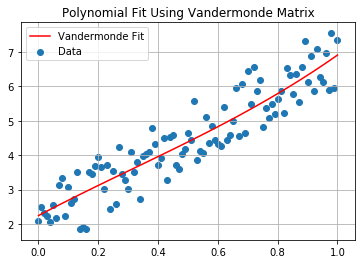

In [13]:
plt.figure()
plt.scatter(x0, y0, label="Data")
plt.plot(x0, y_pred_vand, color='red', label="Vandermonde Fit")
plt.title("Polynomial Fit Using Vandermonde Matrix")
plt.legend()
plt.grid(True)
plt.show()

As shown by the plot and by our MSE, we can determine that the Vandermonde is mathematically and visually similar to a polyfit of our data with a degree of 3.